In [2]:
# import things
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, Dropout,
    Conv2DTranspose, concatenate, BatchNormalization, LeakyReLU
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers.schedules import ExponentialDecay
from tensorflow.keras import backend as K
from tensorflow.keras.utils import load_img, img_to_array
from sklearn.model_selection import train_test_split
import subprocess  

In [3]:
# REQUIREMENT: Do not add code from Tasks 2 or 4
# REQUIREMENT: All dataset prep (crop/pad/patch/directory structure) must be finalize before attempting this task.
patch_size =256
patch_dir = r"C:\Users\melsh\Downloads\Dataset_24"

In [4]:
def f1(y_true, y_pred):
    # Ensure predictions are binary (0 or 1)
    y_pred = K.round(K.clip(y_pred, 0, 1))
    
    # Calculate True Positives, Precision, and Recall
    TP = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))  # True Positives
    Positives = K.sum(K.round(K.clip(y_true, 0, 1)))    # Actual Positives
    Pred_Positives = K.sum(K.round(K.clip(y_pred, 0, 1)))  # Predicted Positives
    
    # Compute Precision and Recall
    precision = TP / (Pred_Positives + K.epsilon())  # Precision
    recall = TP / (Positives + K.epsilon())         # Recall
    
    # Compute F1 Score
    f1_score = 2 * ((precision * recall) / (precision + recall + K.epsilon()))
    return f1_score

def dice_loss(y_true, y_pred):
    numerator = 2 * tf.reduce_sum(y_true * y_pred)
    denominator = tf.reduce_sum(y_true + y_pred) + tf.keras.backend.epsilon()
    return 1 - numerator / denominator

def combined_loss(y_true, y_pred):
    bce = tf.keras.losses.BinaryCrossentropy()(y_true, y_pred)
    dice = dice_loss(y_true, y_pred)
    return bce + dice

# Add attention blocks before concatenating in the expansive path
def attention_block(skip_connection, gating_signal):
    filters = skip_connection.shape[-1]
    gating_signal = Conv2D(filters, (1, 1), activation='relu')(gating_signal)
    skip_connection = Conv2D(filters, (1, 1), activation='relu')(skip_connection)
    attention = tf.keras.layers.Add()([gating_signal, skip_connection])
    attention = tf.keras.layers.Activation('sigmoid')(attention)
    return tf.keras.layers.Multiply()([skip_connection, attention])


In [5]:
from tensorflow.keras.applications import VGG16

# U-Net model with VGG16 encoder
def simple_unet_model(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS):
    # Load pre-trained VGG16 without the top layer
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS))
    
    # Encoder layers from VGG16
    s = base_model.input  # Input layer from VGG16
    c1 = base_model.get_layer("block1_conv2").output  # First block
    c2 = base_model.get_layer("block2_conv2").output  # Second block
    c3 = base_model.get_layer("block3_conv3").output  # Third block
    c4 = base_model.get_layer("block4_conv3").output  # Fourth block
    c5 = base_model.get_layer("block5_conv3").output  # Fifth block (bottleneck)

    # Add dropout and Conv2D to the bottleneck layer for additional learning capacity
    c5 = Dropout(0.3)(c5)
    c5 = Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c5)

    # Expansive path (Decoder)
    u6 = Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(c5)
    u6 = concatenate([u6, c4])
    c6 = Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u6)
    c6 = Dropout(0.2)(c6)
    c6 = Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c6)

    u7 = Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c6)
    u7 = concatenate([u7, c3])
    c7 = Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u7)
    c7 = Dropout(0.2)(c7)
    c7 = Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c7)

    u8 = Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(c7)
    u8 = concatenate([u8, c2])
    c8 = Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u8)
    c8 = Dropout(0.1)(c8)
    c8 = Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c8)

    u9 = Conv2DTranspose(16, (2, 2), strides=(2, 2), padding='same')(c8)
    u9 = concatenate([u9, c1], axis=3)
    c9 = Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u9)
    c9 = Dropout(0.1)(c9)
    c9 = Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c9)

    outputs = Conv2D(1, (1, 1), activation='sigmoid')(c9)

    model = Model(inputs=[s], outputs=[outputs])
    model.compile(optimizer='adam', loss=combined_loss, metrics=['accuracy', f1])
    model.summary()
    
    return model

In [6]:
# Build U-Net
# REQUIREMENT: Model summary must be visible
model = simple_unet_model(patch_size, patch_size, 3)

58889256/58889256 [==============================] - 4s 0us/step
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 256, 256, 3  0           []                               
                                )]                                                                
                                                                                                  
 block1_conv1 (Conv2D)          (None, 256, 256, 64  1792        ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 block1_conv2 (Conv2D)          (None, 256, 256, 64  36928       ['block1_conv1[0][0]']           
                             

In [8]:
from albumentations import Compose, RandomCrop, HorizontalFlip, ElasticTransform
import numpy as np
import cv2

# Define augmentation pipeline
augmentation = Compose([
    RandomCrop(256, 256),
    HorizontalFlip(p=0.5),
    ElasticTransform(p=0.2)
])

# Function to apply augmentations
def augment_image(image, mask):
    augmented = augmentation(image=image, mask=mask)
    return augmented['image'], augmented['mask']

# Paths for training data
train_images_dir = r"c:\Users\melsh\Downloads\Dataset_24\train_images"
train_masks_dir = r"c:\Users\melsh\Downloads\Dataset_24\train_masks"

# Use ImageDataGenerator to load and preprocess images and masks
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Data augmentation settings for training images and masks
train_image_datagen = ImageDataGenerator(rescale=1.0/255.0)  # Normalize pixel values
train_mask_datagen = ImageDataGenerator(rescale=1.0/255.0)  # Normalize pixel values for masks

# Define image and mask generators for training
train_image_generator = train_image_datagen.flow_from_directory(
    train_images_dir,
    target_size=(256, 256),  # Resize images to 256x256
    batch_size=8,          # Adjust batch size as needed
    class_mode=None,        # No class labels for segmentation
    seed=42                 # Ensure reproducibility
)

train_mask_generator = train_mask_datagen.flow_from_directory(
    train_masks_dir,
    target_size=(256, 256),  # Resize masks to 256x256
    batch_size=8,
    class_mode=None,         # No class labels for segmentation
    color_mode="grayscale",  # Load masks as grayscale
    seed=42                  # Ensure reproducibility
)

# Combine ImageDataGenerator with albumentations
def generator_with_augmentation(image_generator, mask_generator):
    for img_batch, mask_batch in zip(image_generator, mask_generator):
        augmented_images = []
        augmented_masks = []
        for i in range(len(img_batch)):
            img = np.asarray(img_batch[i])  # Convert to NumPy array
            mask = np.asarray(mask_batch[i])
            img, mask = augment_image(img, mask)
            augmented_images.append(img)
            augmented_masks.append(mask)
        yield np.array(augmented_images), np.array(augmented_masks)

# Final augmented training generator
train_generator = generator_with_augmentation(train_image_generator, train_mask_generator)

Found 26400 images belonging to 1 classes.
Found 26400 images belonging to 1 classes.


In [9]:
# Fetch a batch to verify shapes
images, masks = next(train_generator)
print("Images shape:", images.shape)  # Expected: (32, 256, 256, 3)
print("Masks shape:", masks.shape)    # Expected: (32, 256, 256, 1)


Images shape: (8, 256, 256, 3)
Masks shape: (8, 256, 256, 1)


In [10]:
# Setup a generator for validation
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Data augmentation settings for validation images and masks
val_image_datagen = ImageDataGenerator(rescale=1.0/255.0)  # Normalize pixel values
val_mask_datagen = ImageDataGenerator(rescale=1.0/255.0)  # Normalize pixel values for masks

# Paths for validation data
val_images_dir = r"c:\Users\melsh\Downloads\Dataset_24\val_images"
val_masks_dir = r"c:\Users\melsh\Downloads\Dataset_24\val_masks"

# Define image and mask generators for validation
val_image_generator = val_image_datagen.flow_from_directory(
    val_images_dir,
    target_size=(256, 256),  # Resize images to 256x256
    batch_size=16,          # Adjust batch size as needed
    class_mode=None,        # No class labels for segmentation
    seed=42                 # Ensure reproducibility
)

val_mask_generator = val_mask_datagen.flow_from_directory(
    val_masks_dir,
    target_size=(256, 256),  # Resize masks to 256x256
    batch_size=16,
    class_mode=None,         # No class labels for segmentation
    color_mode="grayscale",  # Load masks as grayscale
    seed=42                  # Ensure reproducibility
)

# Combine the image and mask generators into a single validation generator
val_generator = zip(val_image_generator, val_mask_generator)


Found 5000 images belonging to 1 classes.
Found 5000 images belonging to 1 classes.


In [11]:
# Fetch a batch to verify shapes
val_images, val_masks = next(val_generator)
print("Validation Images shape:", val_images.shape)  # Expected: (32, 256, 256, 3)
print("Validation Masks shape:", val_masks.shape)    # Expected: (32, 256, 256, 1)


Validation Images shape: (16, 256, 256, 3)
Validation Masks shape: (16, 256, 256, 1)


In [12]:
# EarlyStopping()
from keras.callbacks import EarlyStopping
cb = EarlyStopping(
    monitor='val_loss',  # Metric to monitor ('val_loss', 'val_accuracy', etc.)
    patience=5,          # Number of epochs to wait after the last improvement
    verbose=1,           # Display stopping details
    restore_best_weights=True  # Restore the weights of the best epoch
)

In [13]:
# This is where the magic happens
# REQUIREMENT: The epoch logs must be visible showing validation loss and validation f1.

from tensorflow.keras.callbacks import ReduceLROnPlateau

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1,
    min_lr=1e-6
)

checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_f1',
    save_best_only=True,
    mode='max',
    verbose=1
)


history = model.fit(
    train_generator,                     # Training generator (images and masks zipped together)
    validation_data=val_generator,       # Validation generator (images and masks zipped together)
    epochs=100,                          # Number of epochs to train
    steps_per_epoch=len(train_image_generator),  # Steps per epoch (based on batches in training data)
    validation_steps=len(val_image_generator),   # Validation steps per epoch
    callbacks=[cb],                      # Add EarlyStopping callback
    verbose=1                            # Verbose output to show progressS
)

Epoch 1/100
3300/3300 [==============================] - 585s 173ms/step - loss: 0.6662 - accuracy: 0.9950 - f1: 0.3801 - val_loss: 0.3779 - val_accuracy: 0.9975 - val_f1: 0.6471
Epoch 2/100
3300/3300 [==============================] - 547s 166ms/step - loss: 0.5075 - accuracy: 0.9972 - f1: 0.5195 - val_loss: 0.3733 - val_accuracy: 0.9976 - val_f1: 0.6528
Epoch 3/100
3300/3300 [==============================] - 547s 166ms/step - loss: 0.4806 - accuracy: 0.9974 - f1: 0.5432 - val_loss: 0.3162 - val_accuracy: 0.9980 - val_f1: 0.7051
Epoch 4/100
3300/3300 [==============================] - 546s 166ms/step - loss: 0.4663 - accuracy: 0.9976 - f1: 0.5558 - val_loss: 0.3245 - val_accuracy: 0.9981 - val_f1: 0.6942
Epoch 5/100
3300/3300 [==============================] - 547s 166ms/step - loss: 0.4564 - accuracy: 0.9977 - f1: 0.5649 - val_loss: 0.3530 - val_accuracy: 0.9979 - val_f1: 0.6688
Epoch 6/100
3300/3300 [==============================] - 546s 165ms/step - loss: 0.4523 - accuracy: 0.997

In [14]:
# REQUIREMENT: Save your model, it is a deliverable
# REQUIREMENT: naming convention 'studentname_studentnumber_unet_model_patchsizepx.h5'
example_file_name = f'MohamedElshami_233464_unet_model_1_{patch_size}px.h5'
print(example_file_name)
model.save(example_file_name)

MohamedElshami_233464_unet_model_1_256px.h5


In [15]:
# REQUIREMENT: Run and display the output of this cell.
# REQUIREMENT: Do not change the code.
best_val_loss = min(history.history['val_loss'])
best_val_f1 = max(history.history['val_f1'])
print(f"Best validation loss: {best_val_loss}")
print(f"Best validation f1: {best_val_f1}")

Best validation loss: 0.31621307134628296
Best validation f1: 0.7050879001617432


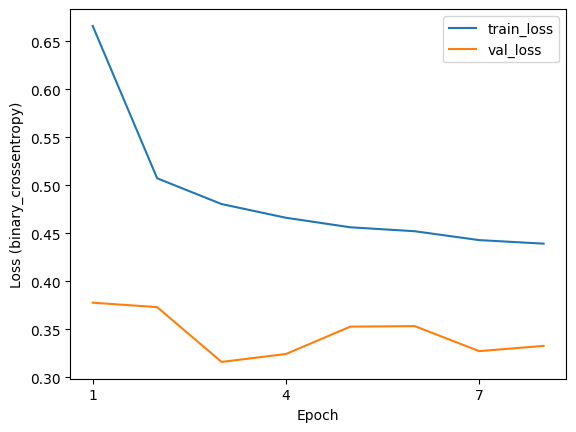

In [16]:
# REQUIREMENT: Run and display the output of this cell.
# REQUIREMENT: Do not change the code.
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = np.arange(1, len(loss) + 1)

plt.plot(epochs, loss, label='train_loss')
plt.plot(epochs, val_loss, label='val_loss')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss (binary_crossentropy)')
_ = plt.xticks(np.arange(1, len(loss) + 1, 3))

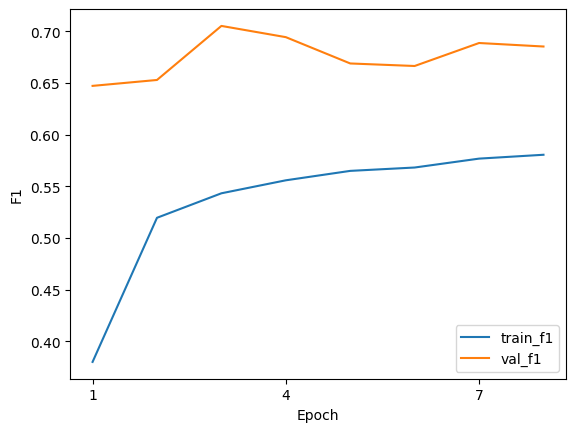

In [17]:
# REQUIREMENT: Run and display the output of this cell.
# REQUIREMENT: Do not change the code.
train_f1 = history.history['f1']
val_f1 = history.history['val_f1']

epochs = np.arange(1, len(train_f1) + 1)

plt.plot(epochs, train_f1, label='train_f1')
plt.plot(epochs, val_f1, label='val_f1')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('F1')
_ = plt.xticks(np.arange(1, len(loss) + 1, 3))